In [3]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
esm_cont = '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json'
esm_bs1 = '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151/datastore.json'
esm_bs2 = '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36/datastore.json'

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [4]:
# if not papermill: 
#     import nci_ipynb, os  # requires conda/analysis3-26.03 or later
#     cwd = nci_ipynb.dir()
#     nbname = nci_ipynb.name()
#     os.chdir(cwd)
# from mkfigs_configdoc import MkmdWriter
# mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [5]:
import nci_ipynb, os
import xarray as xr
import gsw
import intake
from dask.distributed import Client
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
from shapely import geometry
import calendar
import cftime
import textwrap
import numpy as np
from tqdm.notebook import tqdm
import xgcm
from scipy.io import loadmat
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
xr.set_options(keep_attrs=True);
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


In [6]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46525,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35557,Total threads: 1
Dashboard: /proxy/34745/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:38565,


In [7]:
IAF = esm_cont.find('iaf') > 0
IAF

True

In [8]:
catalogs = [esm_cont,
            esm_bs1,
            esm_bs2
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36/datastore.json']

In [9]:
om3datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c,
                                         columns_with_iterables=[
                                            "variable",
                                            "variable_long_name",
                                            "variable_standard_name",
                                            "variable_cell_methods",
                                            "variable_units"]
                                        )
              for c in catalogs }
om3datastores

{'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>,
 'MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151': <datastore catalog with 16 dataset(s) from 2908 asset(s)>,
 'MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36': <datastore catalog with 16 dataset(s) from 2190 asset(s)>}

In [10]:
fields = {
    "speed": None,
    "uo": "u",
    "vo": "v",
    "umo_2d": None,
    "vmo_2d": None,
}

depths = [0, 1000]

raw = {
    vname: {expt: ds.search(variable=vname, frequency="1mon").to_dask(
                xarray_open_kwargs=dict(decode_timedelta=True, use_cftime=True)
            )[vname]
            for expt, ds in om3datastores.items()}
    for vname in fields
}

# common time range
datastop  = np.min([raw['uo'][e].time.values[-1] for e in raw['uo']])
datastart = np.max([raw['uo'][e].time.values[0] for e in raw['uo']])
nyears = 30
datastart = np.max([datastart, cftime.datetime(cftime.to_tuple(datastop)[0]-nyears+1, 1, 1, calendar=datastop.calendar)])
datestart = cftime.datetime(cftime.to_tuple(datastart)[0], 1, 1, calendar=datastop.calendar)
datestop  = cftime.datetime(cftime.to_tuple(datastop)[0], 12, 31, 23, 59, 59, calendar=datastop.calendar)
timeslice = slice(datestart, datestop)

# depths before time averaging
data = {}
for vname, dct in raw.items():
    data[vname] = {}
    for expt, da in dct.items():
        d = da.sel(time=timeslice)
        if 'z_l' in d.dims:
            d = d.sel(z_l=depths, method='nearest')
        data[vname][expt] = d.mean('time')

In [11]:
exptname = 'MC_25km_jra_iaf+wombatlite-test3v2-00532b88'
static = xr.open_dataset(om3datastores[exptname].search(filename="access-om3.mom6.static.nc").df.loc[0, "path"]).drop_vars("time")

In [12]:
# See https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6/#xgcm-grid-definition
symmetric = True  # True for ACCESS-OM3 2025.08.000 and later

if symmetric:  # ACCESS-OM3 version 2025.08.000 and later: one more q point than h points
    coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }
else:  # ACCESS-OM3 versions prior to 2025.08.000: equal number of q and h points
    coords={
        'X': {'center': 'xh', 'right': 'xq'},
        'Y': {'center': 'yh', 'right': 'yq'},
        # 'Z': { 'inner': 'z_l', 'outer': 'z_i'}
    }

grid = xgcm.Grid(
    static,
    coords=coords,
    metrics = {
        ('X',): ['dxt', 'dxCu', 'dxCv'], # X distances
        ('Y',): ['dyt', 'dyCu', 'dyCv'], # Y distances
        ('X', 'Y'): ['areacello', 'areacello_cu', 'areacello_cv', 'areacello_bu'] # Areas
    },
    periodic=['X'],
    autoparse_metadata=False
# Note, autoparse_metadata=False is required below for xgcm >= 0.9.0 to prevent xgcm 
# from trying to autoparse non-existent grid information from the file metadata, 
# leading to the error:
# ValueError: Found two coordinates without `c_grid_axis_shift` attribute for axis X
)

Text(0.5, 1.0, 'Regions (BUG: incorrect shapes north of 65°N)')

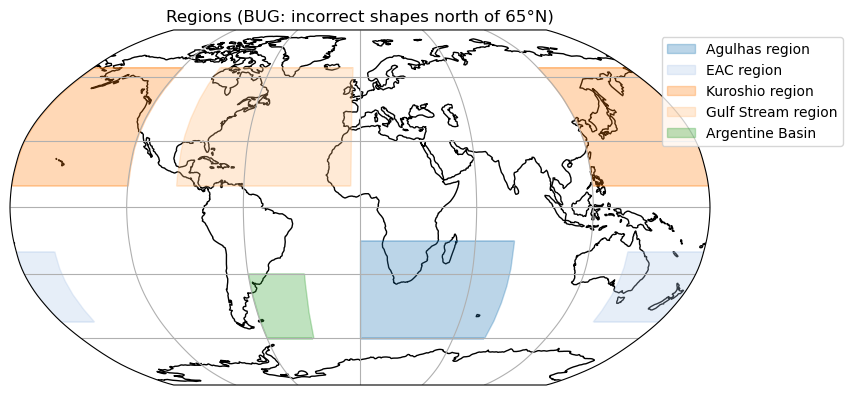

In [14]:
regions = { # [minx, maxx, miny, maxy], using model longitude range (-280 to 80)
    "Agulhas region": [0, 80, -60, -15],  # fig 16 in Kiss et al 2020
    "EAC region": [-220, -160, -52, -20],  # fig 17 in Kiss et al 2020
    "Kuroshio region": [-240, -120, 10, 65],  # fig 21 in Kiss et al 2020
    "Gulf Stream region": [-95, -5, 10, 65],  # fig 22 in Kiss et al 2020
    "Argentine Basin": [-60, -30, -60, -30],  # fig 24 in Kiss et al 2020
    # "Global": [-280, 80, -90, 90],
    # "Arctic": [-280, 80, 65, 90],
    # "Southern Ocean": [-280, 80, -82, -63],
    # "ACC": [-280, 80, -63, -45],
    # "Southern Pacific": [-210, -70, -45, -20],
    # "Tropical Pacific": [-240, -100, -20, 20],
    # "North Pacific": [-240, -100, 20, 65],
    # "South Atlantic": [-60, 20, -45, -20],
    # "Tropical Atlantic": [-70, 20, -20, 20],
    # "North Atlantic": [-100, 0, 20, 65],
    # "Indian": [30, 120, -45, 20],
    # "Aegean Sea": [18, 27.5, 34, 44],
    # "Black Sea": [27.5, 43, 40.5, 48],
    # "Baltic Sea": [13, 30, 53, 58],
    # "Mediterranean Sea": [0, 35, 31, 41],
    # "Red Sea": [33, 44, 12, 29],
    # "Persian Gulf": [47, 56, 24, 31],
    # "White Sea": [31, 41, 63, 68],
}
regions = {k: dict(zip(["minx", "maxx", "miny", "maxy"], v)) for k, v in regions.items()}  # convert to dicts

for r, d in regions.items():
    for k, x in d.items():
        if k in ["minx", "maxx"] and x != max(-280, min(x, 80)):
            raise ValueError(f"{r} {k} = {x} is outside the range -280 to 80")

fig = plt.figure(figsize=(10, 4))

colors = mpl.color_sequences['tab20']
try:  # set Global color to white 
    colors[list(regions.keys()).index("Global")] = (1, 1, 1)
except ValueError:
    pass

ax = plt.axes(position=[0.05,0.05,0.7,0.9], projection=ccrs.Robinson())
ax.coastlines(resolution="110m")
ax.gridlines(draw_labels=False)

legend_elements = []
for i, (region, limits) in enumerate(regions.items()):
    ax.add_geometries([geometry.box(**limits)], crs=ccrs.PlateCarree(), color=colors[i], alpha=0.3)
    legend_elements.append(Patch(color=colors[i], alpha=0.3, label=region))

ax.legend(handles=legend_elements, bbox_to_anchor=(1.2, 1.00))
plt.title("Regions (BUG: incorrect shapes north of 65°N)")

In [15]:
# interpolate to NE corner
interp_axis = {"uo": "Y", "vo": "X"}
coord = {"uo": "yh", "vo": "xh"}
for vname in interp_axis:
    data[vname+"_ne"] = {}
    for expt, da in data[vname].items():
        v = grid.interp(da.chunk(chunks={coord[vname]: -1}), interp_axis[vname], boundary="extend")
        v = v.assign_coords({"z_l": da.z_l, "geolon_c": static.geolon_c, "geolat_c": static.geolat_c})
        data[vname+"_ne"][expt] = v

# speed
speed = {}
for expt in om3datastores:
    u = data['uo_ne'][expt]
    v = data['vo_ne'][expt]
    speed[expt] = np.sqrt(u**2 + v**2)

from dask import compute
expts = list(speed.keys())
computed = compute(*[speed[e] for e in expts])
speed = dict(zip(expts, computed))

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.06/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 79.48 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Agulhas region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Agulhas region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Agulhas region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
EAC region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
EAC region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
EAC region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Kuroshio region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Kuroshio region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Kuroshio region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Gulf Stream region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Gulf Stream region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Gulf Stream region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Argentine Basin MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Argentine Basin MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Argentine Basin MC_25km_jra_iaf+wombatlite_bs2-mpudi

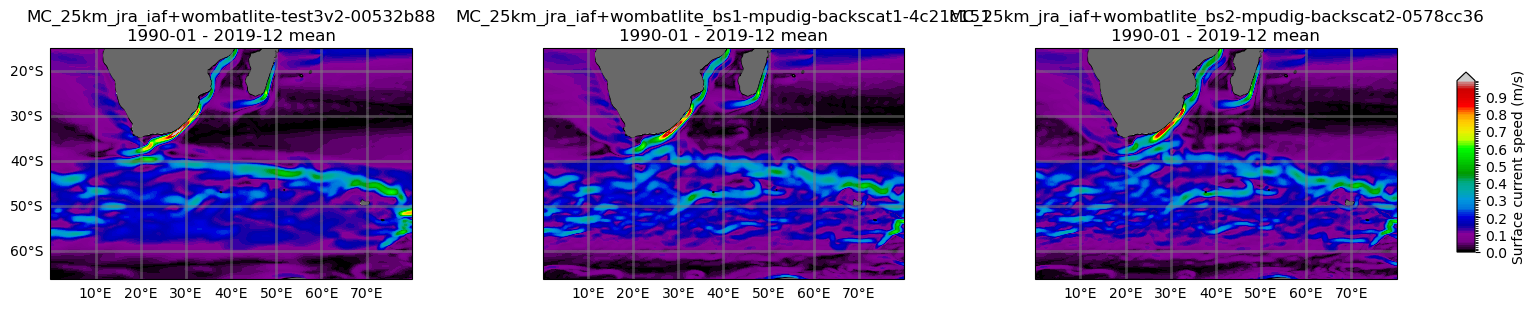

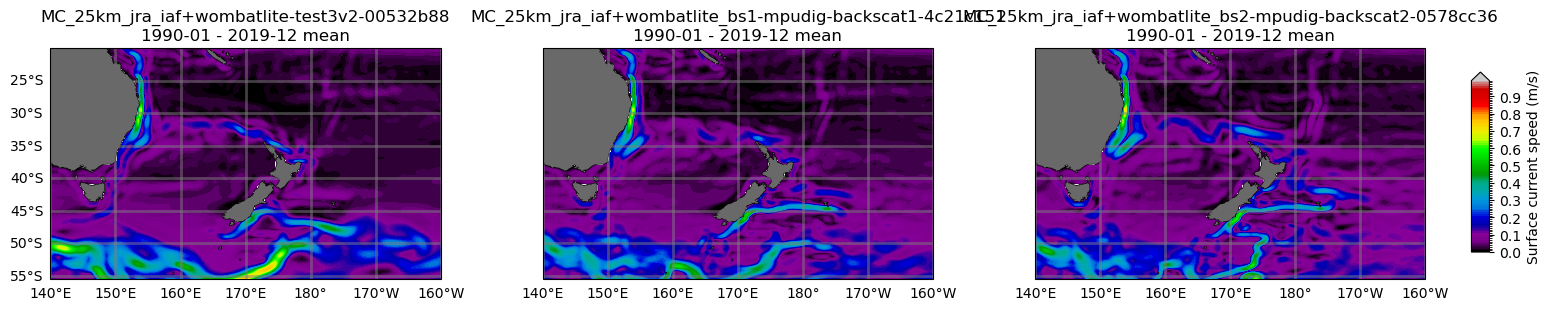

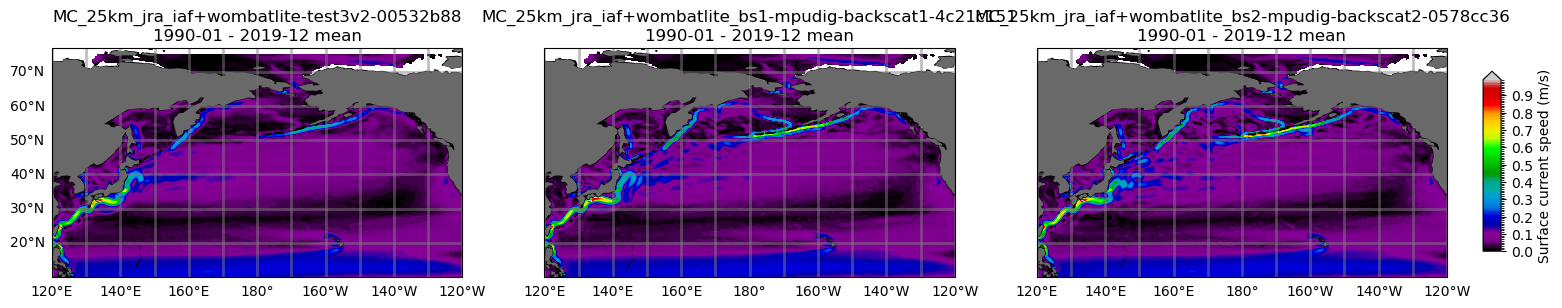

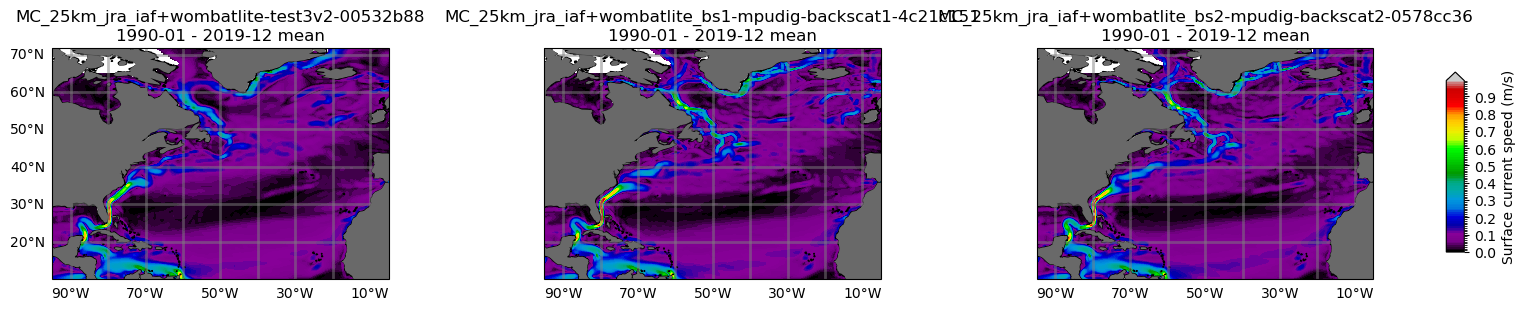

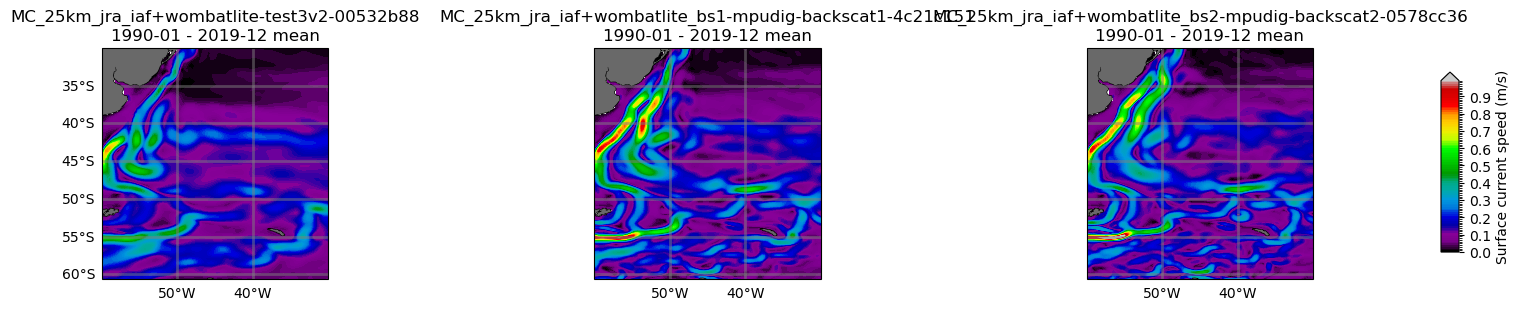

In [25]:
depth = 0.

margin = 10
cmp = plt.get_cmap('nipy_spectral')
clev1 = np.arange(0, 1.0, 0.01)
for region, bounds in regions.items():
    minx, maxx, miny, maxy = bounds.values()
    xslice = slice(minx-margin, maxx+margin)
    yslice = slice(miny-margin, maxy+margin)
    ncols = len(speed)
    proj = ccrs.PlateCarree(central_longitude=(minx+maxx)/2)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 3), subplot_kw=dict(projection=proj, frame_on=False))
    for i, (expt, da) in enumerate(speed.items(), start=1):
        print(region, expt)
        ax = plt.subplot(1, ncols, i, projection=proj)
        d = da.sel(z_l = depth, method='nearest').sel(xq=xslice, yq=yslice)  # already in memory — instant
        p1 = d.plot.contourf(cmap=cmp, levels=clev1, add_colorbar=False, extend='max', transform=ccrs.PlateCarree())
        p1.cmap.set_over(color=cmp(255), alpha=None)
        plt.title(f"{expt}\n{datestart.strftime('%Y-%m')} - {datestop.strftime('%Y-%m')} mean")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='-')
        gl.top_labels = False
        gl.right_labels = False
        if i > 1:
            gl.left_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
        ax.add_feature(cft.LAND, facecolor='dimgray', zorder=2)
        ax.coastlines(resolution="50m")
        ax.set_extent(bounds.values())
    ax1 = plt.axes([0.92, 0.2, 0.01, 0.6])
    cb = plt.colorbar(p1, cax=ax1, orientation='vertical', pad=.05)
    cb.ax.set_ylabel('Surface current speed (m/s)')

Agulhas region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Agulhas region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Agulhas region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
EAC region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
EAC region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
EAC region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Kuroshio region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Kuroshio region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Kuroshio region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Gulf Stream region MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Gulf Stream region MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Gulf Stream region MC_25km_jra_iaf+wombatlite_bs2-mpudig-backscat2-0578cc36
Argentine Basin MC_25km_jra_iaf+wombatlite-test3v2-00532b88
Argentine Basin MC_25km_jra_iaf+wombatlite_bs1-mpudig-backscat1-4c21c151
Argentine Basin MC_25km_jra_iaf+wombatlite_bs2-mpudi

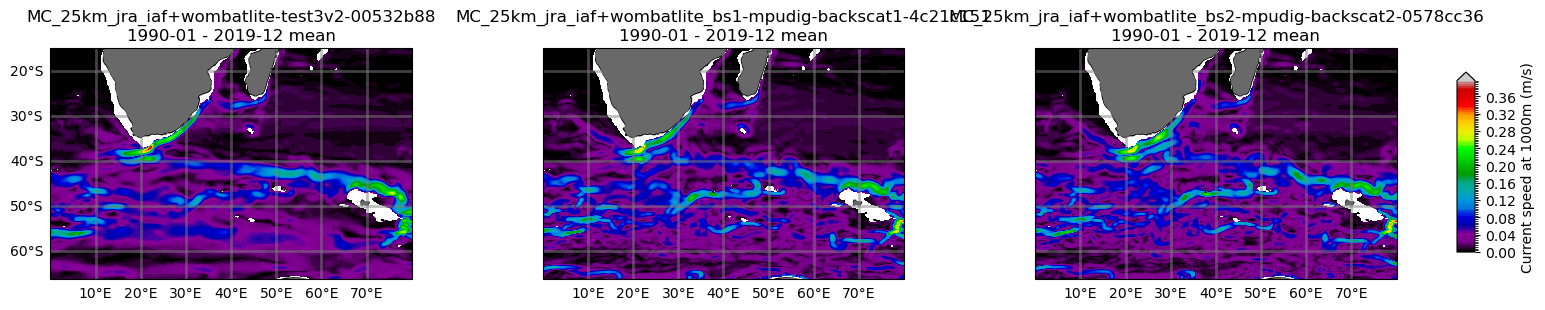

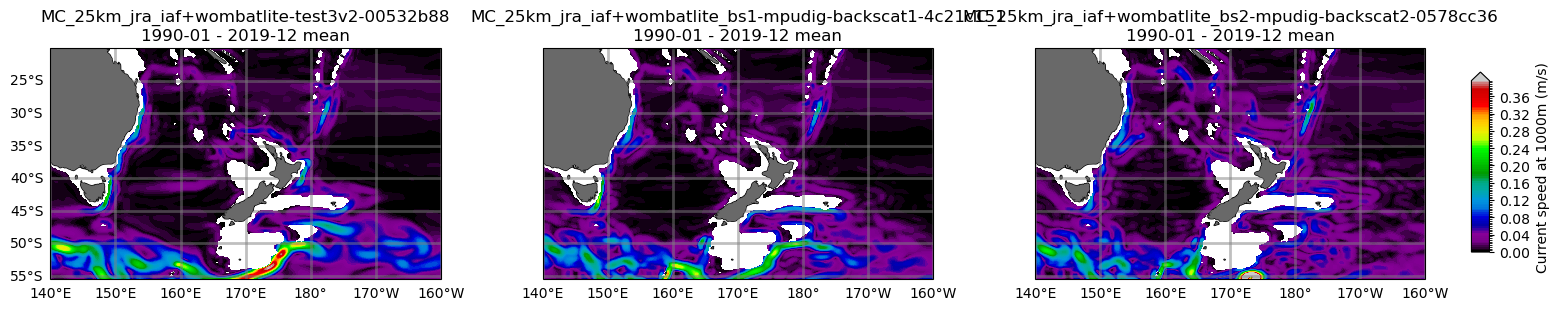

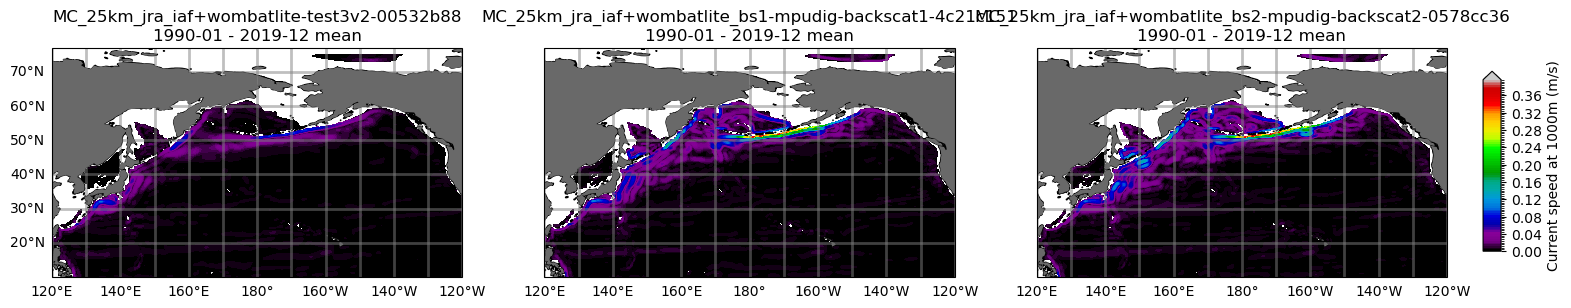

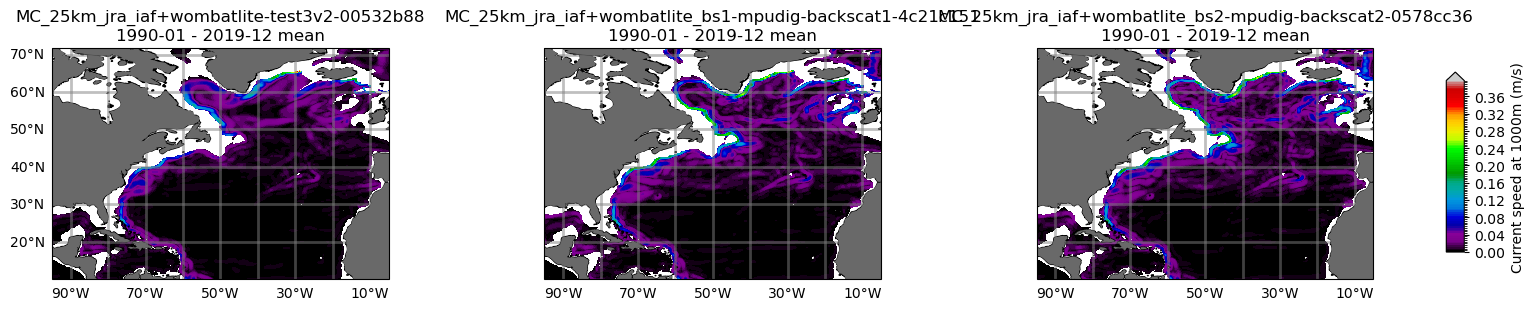

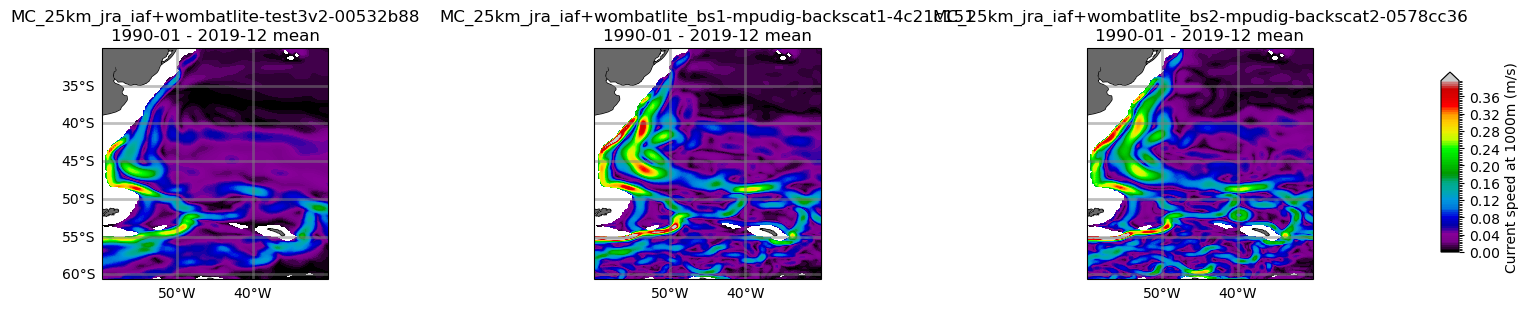

In [27]:
depth = 1000.

margin = 10
cmp = plt.get_cmap('nipy_spectral')
clev1 = np.arange(0, 1.0, 0.01) * 0.4
for region, bounds in regions.items():
    minx, maxx, miny, maxy = bounds.values()
    xslice = slice(minx-margin, maxx+margin)
    yslice = slice(miny-margin, maxy+margin)
    ncols = len(speed)
    proj = ccrs.PlateCarree(central_longitude=(minx+maxx)/2)
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 3), subplot_kw=dict(projection=proj, frame_on=False))
    for i, (expt, da) in enumerate(speed.items(), start=1):
        print(region, expt)
        ax = plt.subplot(1, ncols, i, projection=proj)
        d = da.sel(z_l = depth, method='nearest').sel(xq=xslice, yq=yslice)  # already in memory — instant
        p1 = d.plot.contourf(cmap=cmp, levels=clev1, add_colorbar=False, extend='max', transform=ccrs.PlateCarree())
        p1.cmap.set_over(color=cmp(255), alpha=None)
        plt.title(f"{expt}\n{datestart.strftime('%Y-%m')} - {datestop.strftime('%Y-%m')} mean")
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='-')
        gl.top_labels = False
        gl.right_labels = False
        if i > 1:
            gl.left_labels = False
        gl.xlocator = mticker.FixedLocator(np.arange(-270, 180, 10))
        ax.add_feature(cft.LAND, facecolor='dimgray', zorder=2)
        ax.coastlines(resolution="50m")
        ax.set_extent(bounds.values())
    ax1 = plt.axes([0.92, 0.2, 0.01, 0.6])
    cb = plt.colorbar(p1, cax=ax1, orientation='vertical', pad=.05)
    cb.ax.set_ylabel('Current speed at 1000m (m/s)')